In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statistics
import numpy as np
pathToFolder = ""
plt.rcParams.update({'font.size': 10})

results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

all_throughput_results = []
all_median_fairness_results = []
all_max_fairness_results = []
all_time_results = []
all_first2_results = []

util_with_udp_array = []

labels = []

fifo_or_cebinae = ""

In [2]:
def plot():
    # throughput calculation
    time_1 = []
    time_2 = []
    time_3 = []
    time_4 = []
    throughput_array_1 = []
    throughput_array_2 = []
    throughput_array_3 = []
    throughput_array_4  = []
    throughput_array_udp = []
    packet_drop_1 = []
    packet_drop_2 = []
    packet_drop_3 = []
    packet_drop_4 = []
            
    # if any file is does not have entries that go until [duration--30s], print error and change experiments    
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        if (last_time_of_file < 29):
            print("error in file 0-0-1.out")
            print(last_time_of_file)
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        last_line_of_file = rf.readlines()[-1]
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-2.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-3.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-4.out")
            print(last_time_of_file)

    ################################################ throughput ###########################################################
    # # # # # # # # # # # # # # # # # # # # # # # #  four flows # # # # # # # # # # # # # # # # # # # # # # # # # # #

    time_total_throughput = []
    total_throughput_array = []

    prev_recorded_time: float = 0
    total_time: float = 0
    total_size: float = 0
    time_index = 0.1
    total_throughput_array = []

    # total throughput

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full-throughput-sorted.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_total_throughput.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                total_throughput_array.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time


    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now

    # throughput 1
    prev_seq_number: float = 0
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_1.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                throughput_array_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    # throughput 2

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            # bookmark first_index_in_array_from_data_2 for throughput calculations later (measuring throughput of first second)
            first_index_in_array_from_data_2 = first_index_in_array_from_data
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_2.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    inserted_all_new_indices = False
    # compare time_index (0.1) to first time in file 0-0-2 (time when first packet is received)
    while (time_index < first_index_in_array_from_data):
        # insert time_index in time array to fill time (to match length of time_1)--match flow start time
        time_2.insert(index, round(time_index, 2))
        throughput_array_2.insert(index, 0)
        index += 1
        time_index += 0.1
        # when time_index has reached the first time in the file (when flow starts), stop inserting new values
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    # if flow stops just before 29.9 (between 19 and 29.9--see above for error for flow stopping before 19s)
    # append time_index and throughput = 0 until array lengths are the same
    last_time_index = time_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_2.append(round(last_time_index, 2))
        throughput_array_2.append(0)


    # throughput 3

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_3.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_3.insert(index, round(time_index, 2))
        throughput_array_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_3.append(round(last_time_index, 2))
        throughput_array_3.append(0)

    # throughput 4

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_4.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_4.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_4.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_4.insert(index, round(time_index, 2))
        throughput_array_4.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_4[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_4.append(round(last_time_index, 2))
        throughput_array_4.append(0)
  
    # udp
        # udp
    time_udp_1 = []
    throughput_array_udp_1 = []
    time_udp_2 = []
    throughput_array_udp_2 = []
    time_udp_3 = []
    throughput_array_udp_3 = []
        
    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_1.insert(index, round(time_index, 2))
        throughput_array_udp_1.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_1[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_1.append(round(last_time_index, 2))
        throughput_array_udp_1.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_2.insert(index, round(time_index, 2))
        throughput_array_udp_2.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_2.append(round(last_time_index, 2))
        throughput_array_udp_2.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_3.insert(index, round(time_index, 2))
        throughput_array_udp_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_3.append(round(last_time_index, 2))
        throughput_array_udp_3.append(0)
        
        
#      # udp
#     time_udp = []
#     throughput_array_udp = []
        
#     prev_time = 0
#     total_time = 0
#     total_size = 0
#     prev_recorded_time = 0
#     last_time = 0
#     time_index = 0.1 # not used right now
#     first_index_in_array_from_data = 0
#     # used to calculate where time_index should be
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
#             first_index_in_array_from_data = time_index
#             break
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             # current time
#             total_time = float(line.split(" IP", 1)[0])

#             # current size
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28
#             size = size * 8
#             total_size += size

#             if (total_time >= time_index):

#                 # add 100 ms interval to time array
#                 time_udp.append(round(time_index, 2))

#                 # add throughput to throughput array
#                 throughput = (total_size - size) / 0.1 # throughput (size / time)

#                 throughput_array_udp.append(throughput / 1000000) # convert bps to Mbps

#                 time_index += 0.1
#                 total_size = size
#                 prev_recorded_time = last_time
#             last_time = total_time

#         time_index = 0.1
#     index = 0
#     while (time_index < first_index_in_array_from_data):
#         time_udp.insert(index, round(time_index, 2))
#         throughput_array_udp.insert(index, 0)
#         index += 1
#         time_index += 0.1
#         if (time_index == first_index_in_array_from_data):
#             inserted_all_new_indices = True

#     last_time_index = time_udp[-1]
#     while (last_time_index < last_time_of_file):
#         last_time_index += 0.1
#         time_udp.append(round(last_time_index, 2))
#         throughput_array_udp.append(0)

#     ############################### queue #######################################################
#     line_number = 0
#     prev_sign = "-"
#     duplicate_line = 0 

#     dropped_packets = [] # array that contains all times where packets were dropped
#     dropped_packets_markers = []
#     prev_time = 0

#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full_sorted_duplicates_TCP.out', 'r') as file:
#         for line in file:
#             line_number += 1
#             adjusted_size = 0

#             sign = line.split(" ", 1)[0]
#             temp_time = line.split(" IP", 1)[0]
#             time = float(temp_time.split(" ")[1])

#             # find size to add to queue
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28

#             size = size * 8
#             adjusted_size += size
#             # if it's TCP traffic, check that signs do not match
#             if (not line.__contains__("UDP")):
#                 if (prev_sign == "-" and sign != "+"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)
#                 elif (prev_sign == "+" and sign != "-"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)

#             prev_sign = sign
#             prev_line = line
#             prev_time = time

    # total with all udp

    total_throughput_with_all_udp = []
    
#     for index in range (0, len(time_1)):
#         total_throughput_with_all_udp.append(total_throughput_array[index] + throughput_array_udp_1[index] + throughput_array_udp_2[index] + throughput_array_udp_3[index])

            
    # creating new np arrays so that slice operation can be performed
    np_array_1 = np.array(throughput_array_1)
    np_array_2 = np.array(throughput_array_2)
    np_array_3 = np.array(throughput_array_3)
    np_array_4 = np.array(throughput_array_4)  
    
#     np_throughput_array_udp = np.array(throughput_array_udp)

    # calculate ratio between max/min of four flows using slicing window
    for index in range(40, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])
        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0

    # find utilization from 6s--> (total throughput)
    utilization_array_total_throughput = []
    for index in range (60, len(time_1)):  
#         utilization_array_total_throughput.append(np_throughput_array_udp[index] + throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
        utilization_array_total_throughput.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_after_60_total_throughput = statistics.mean(utilization_array_total_throughput)
#     print("utilization 6s--> (total throughput): " + str(statistics.mean(utilization_array_total_throughput)))

    # find utilization of last 5 seconds
    utilization_array = []
    for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
        utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_last5 = statistics.mean(utilization_array)
#     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))

#     utilization_array_with_udp = []
#     for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array_with_udp.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
# #         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
#     util_with_udp_last5 = statistics.mean(utilization_array_with_udp)
# #     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))
#     util_with_udp_array.append(util_with_udp_last5)


    # calculate throughput of first flow for 0-2s
    utilization_array_0_2s = []
    for index in range (0, time_1.index(round(first_index_in_array_from_data_2, 1))):
        utilization_array_0_2s.append(throughput_array_1[index])
        util_first2 = statistics.mean(utilization_array_0_2s)

    ratio_array = []

    # calculate ratio between max/min of four flows using slicing window for 15s-18s
    for index in range(len(time_1) - 50, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        if ((index + 20) <= len(time_1)): # ensure that there is enough room for slicing window (15-18s)
            throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])

        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0
            print("Replace this iteration: ", iteration)
        ratio_array.append(ratio)

    ratio_array_np = np.array(ratio_array)

#     results_throughput.append(statistics.mean(utilization_array_with_udp))
    results_throughput.append(statistics.mean(utilization_array))
    results_median_fairness.append(statistics.median(ratio_array))
    results_max_fairness.append(ratio_array_np.max())
    results_first2.append(util_first2)

    # raw fifo only: assigning Raw FIFO median fairness ratio to be used as constraint
    if (raw_fifo):
        rawFIFOMedianFairnessRatio = statistics.median(ratio_array)
    
#     print("median ratio:", statistics.median(ratio_array))
#     print("max ratio: ", ratio_array_np.max())
#     print("udp:", statistics.median(throughput_array_udp))
    
    if (show_plot):
            ################################### plot throughput--and dropped packets (Mbps) #########################################################
        plt.plot(time_1, throughput_array_1, label="Flow 1")
        plt.plot(time_2, throughput_array_2, label="Flow 2")
        plt.plot(time_3, throughput_array_3, label="Flow 3")
        plt.plot(time_4, throughput_array_4, label="Flow 4")
        plt.plot(time_udp_1, throughput_array_udp_1, label="UDP", color='hotpink', alpha=0.5)
        plt.plot(time_udp_2, throughput_array_udp_2, label="UDP", color='gold', alpha=0.5)
        plt.plot(time_udp_3, throughput_array_udp_3, label="UDP", color='indigo', alpha=0.5)
        plt.plot(time_total_throughput, total_throughput_array, label="Total Throughput", color='black')
#         plt.plot(time_total_throughput, total_throughput_with_all_udp, color='grey')
        plt.plot(packet_drop_1, np.full((len(packet_drop_1)), -3, dtype=int), 'bo') # dropped packets
        plt.plot(packet_drop_2, np.full((len(packet_drop_2)), 3, dtype=int), 'o', color='orange') # dropped packets
        plt.plot(packet_drop_3, np.full((len(packet_drop_3)), 0, dtype=int), 'go') # dropped packets
        plt.plot(packet_drop_4, np.full((len(packet_drop_4)), 6, dtype=int), 'ro') # dropped packets

#     plt.legend(['Flow 1', 'Flow 2', 'Flow 3', 'Flow 4', 'Total Throughput'], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xlabel("Time (s)")
        plt.ylabel("Throughput (Mbps)")
        yticks = np.arange(0, 110, 10)
        plt.yticks(yticks)
    #     plt.title("Tax Constant: " + taxConstant + " Median Fairness: " + str(round(median_fairness, 2)))
        plt.show()
        print("median ratio:", statistics.median(ratio_array))

    return results_throughput, results_median_fairness, results_max_fairness, results_first2

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.66352896
median fairness: 2.1067372187390174
max fairness: 2.326830321471835


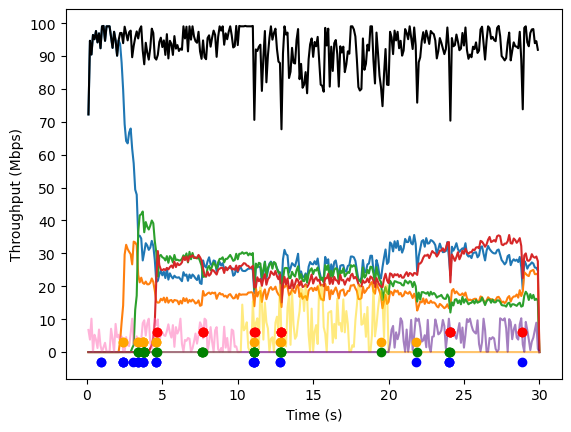

median ratio: 2.091576694786534


([92.7416832,
  94.7629824,
  93.755904,
  93.4797312,
  93.6178176,
  93.4178304,
  94.0606464,
  93.6773376,
  93.3535488,
  93.767808,
  93.6178176],
 [2.5063125810782987,
  2.1705492032696156,
  3.9392440478740447,
  1.5078316042895423,
  2.091576694786534,
  2.121897742691501,
  2.5573101776749407,
  1.8727879998978496,
  1.434314011069036,
  1.4214503895699502,
  2.091576694786534],
 [2.6413502109704643,
  2.3508637236084455,
  28.63450292397661,
  2.378839590443686,
  2.3027969193352247,
  2.1439205955334986,
  2.5787384208204673,
  1.902177793645127,
  1.939966832504146,
  1.43657728231395,
  2.3027969193352247],
 [93.47169684210526,
  93.41827047619047,
  93.333536,
  91.92743619047619,
  94.52393599999999,
  94.73728,
  92.940704,
  93.827552,
  93.08382476190476,
  92.88451555555555,
  94.52393599999999])

In [3]:
iteration = 1
taxConstant = "RawFIFO"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = True
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.218672
median fairness: 1.85641799440839
max fairness: 2.4085348028500246


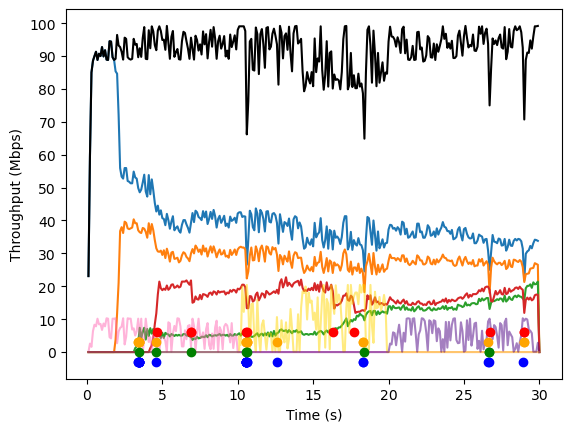

median ratio: 1.8907515328409958


([94.0201728,
  93.755904,
  93.6035328,
  93.7987584,
  94.0225536,
  94.743936,
  95.4653184,
  94.33919999999999,
  94.0201728],
 [1.8907515328409958,
  2.473872264403752,
  1.8220844559757843,
  1.6098222222533387,
  1.7832842903434576,
  1.2096008266320224,
  2.64379736737136,
  2.890592579009192,
  1.8907515328409958],
 [2.255520504731861,
  2.5615491009681883,
  1.9219642177388656,
  1.84375,
  2.6888337468982626,
  1.2996863416025093,
  2.686795491143317,
  3.227224008574491,
  2.255520504731861],
 [84.80302222222222,
  87.83192888888888,
  87.75151157894737,
  86.61123368421053,
  85.61505684210526,
  85.02126222222222,
  86.03971555555556,
  86.12568888888889,
  84.80302222222222])

In [4]:
iteration = 1
taxConstant = "100000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.6555488
median fairness: 1.7322812352074568
max fairness: 1.7966726893575615


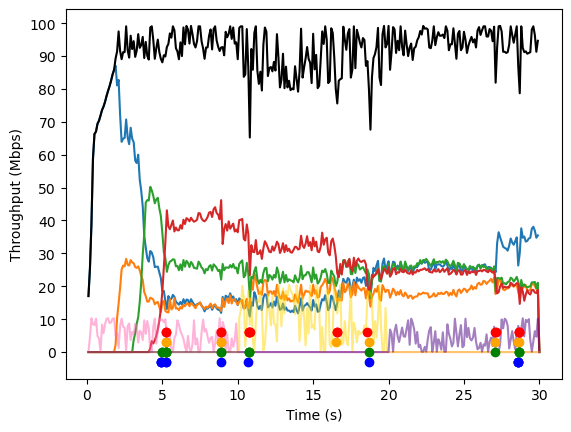

median ratio: 1.7218329704406354


([94.7963136,
  95.3224704,
  96.5747712,
  93.874944,
  93.8439936,
  93.9963648,
  94.493952,
  94.3415808,
  94.493952],
 [1.9739161085653862,
  3.995789583913884,
  1.6525619834710745,
  1.8913477770778964,
  1.265808297567954,
  1.3418343909565302,
  1.7218329704406354,
  1.7427294999742782,
  1.7218329704406354],
 [1.9835104433858557,
  4.09689557855127,
  1.7273923051627755,
  1.9398117014122396,
  1.7045157068062826,
  1.4513993379476378,
  1.8179519595448796,
  1.7753934191702434,
  1.8179519595448796],
 [79.31486476190476,
  71.30519578947369,
  77.95440761904761,
  68.918432,
  78.65731047619047,
  77.33456,
  66.69571555555555,
  73.13612190476191,
  66.69571555555555])

In [5]:
iteration = 1
taxConstant = "250000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.0067808
median fairness: 1.9605695131182561
max fairness: 2.1158112962358055


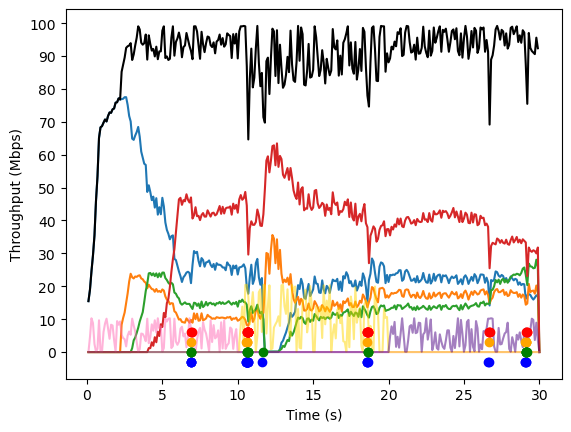

median ratio: 1.8692697768762678


([93.5368704,
  93.2868864,
  94.5725184,
  93.6178176,
  94.0249344,
  94.2368256,
  94.68917760000001,
  94.089216,
  94.0249344],
 [2.8045692451591075,
  1.2099037138927098,
  2.087773040326634,
  1.3833789390939213,
  1.8692697768762678,
  1.3553299492385789,
  2.616965662148428,
  2.0518692493602444,
  1.8692697768762678],
 [2.9661482159194876,
  1.2241813602015112,
  2.1481757259865972,
  1.3884032634032635,
  2.6183206106870225,
  1.368275438057178,
  2.622786022020105,
  2.0834468664850134,
  2.6183206106870225],
 [57.03824,
  59.903822222222225,
  59.236784761904765,
  58.984544,
  58.5735619047619,
  58.990496,
  57.352454736842105,
  58.012408888888885,
  58.5735619047619])

In [6]:
iteration = 1
taxConstant = "500000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 93.8722656
median fairness: 1.8037962663757234
max fairness: 1.9333272693605865


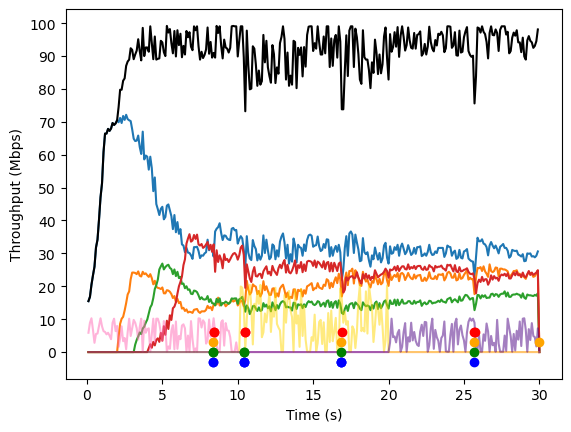

median ratio: 1.7440774736588052


([94.14159360000001,
  94.589184,
  92.7535872,
  93.8654208,
  94.5439488,
  94.2582528,
  94.06302720000001,
  92.7631104,
  94.589184],
 [2.3167244367417674,
  1.7440774736588052,
  2.08864117175622,
  1.7364597179387948,
  1.863515059092642,
  2.471154492144386,
  1.2588577287548102,
  1.70641117782237,
  1.7440774736588052],
 [2.4557421697684974,
  1.8899504600141543,
  2.202318623784592,
  1.933086876155268,
  1.9335676625659048,
  3.6438690766976065,
  1.8138513513513512,
  1.8362633574629437,
  1.8899504600141543],
 [50.14439619047619,
  49.098272,
  48.512168421052635,
  47.40647619047619,
  45.874492631578946,
  47.419808,
  46.05550222222222,
  48.05269333333333,
  49.098272])

In [7]:
iteration = 1
taxConstant = "750000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 93.4975872
median fairness: 2.104232218769701
max fairness: 2.3078560644972392


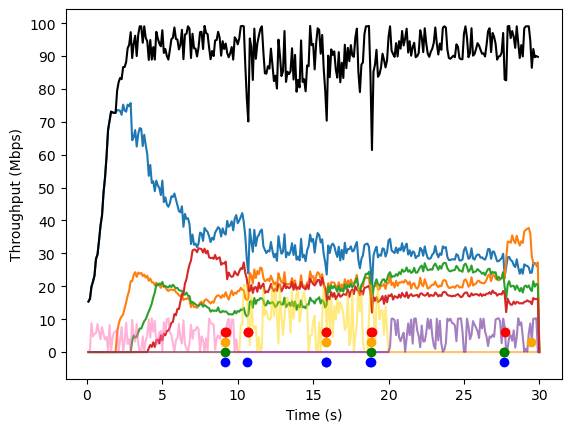

median ratio: 2.094927310164098


([93.9892224,
  93.7701888,
  93.7344768,
  93.33212160000001,
  93.0035712,
  93.517824,
  92.9750016,
  93.65829120000001,
  93.33212160000001],
 [2.6573105475669223,
  5.165772482592155,
  1.3785390627375849,
  2.094927310164098,
  1.969267955801105,
  1.8055921052631578,
  2.113537127375304,
  2.6123195890507525,
  2.094927310164098],
 [2.9136979427998,
  5.244834063869757,
  1.8972972972972975,
  2.2174772637406086,
  2.0239099859353025,
  2.38650827322868,
  2.2292038557657983,
  2.7209585702680745,
  2.2174772637406086],
 [41.254222222222225,
  43.531284210526316,
  43.687903999999996,
  45.16025263157895,
  45.854432,
  42.31896888888889,
  42.87248,
  42.860576,
  45.16025263157895])

In [8]:
iteration = 1
taxConstant = "900000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.1347488
median fairness: 2.08765015449235
max fairness: 2.6013760048724253


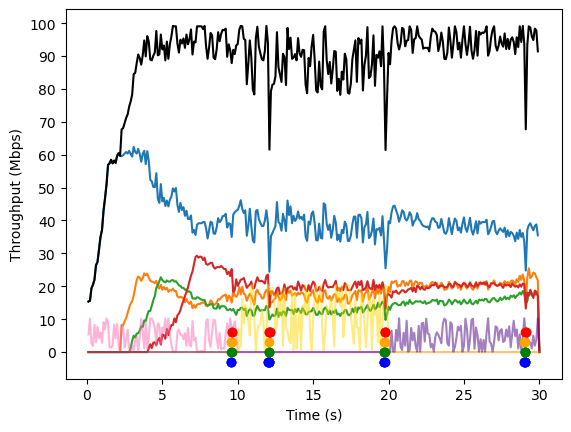

median ratio: 2.1128834522762245


([94.44157440000001,
  94.386816,
  94.5963264,
  93.8249472,
  93.89399039999999,
  93.898752,
  94.2130176,
  93.8225664,
  94.386816],
 [1.7414998719384167,
  2.1128834522762245,
  2.6638508848211604,
  1.519303016864717,
  1.9188035498251603,
  2.9730280215853706,
  6.494416483463342,
  2.0624168567084755,
  2.1128834522762245],
 [1.758837132474397,
  2.484032320123124,
  2.7187196896217265,
  1.6292794261493315,
  1.9348804987876687,
  3.1577114427860695,
  6.725874125874126,
  2.7235063235935457,
  2.484032320123124],
 [40.9312,
  40.7969219047619,
  38.47000888888889,
  41.51683047619048,
  41.759456,
  40.924934736842104,
  38.26499555555556,
  44.260419047619045,
  40.7969219047619])

In [9]:
iteration = 1
taxConstant = "1000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 93.812448
median fairness: 1.8085210907100921
max fairness: 2.273289710268198


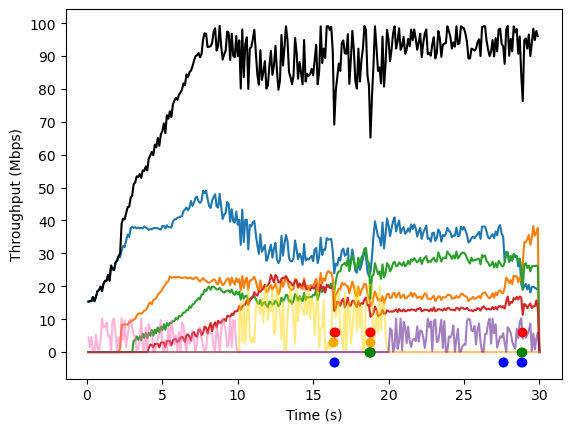

median ratio: 1.9508856682769729


([94.624896,
  93.4440192,
  93.81542400000001,
  94.2653952,
  93.7606656,
  93.9749376,
  93.9273216,
  92.6869248,
  93.7606656],
 [1.234215885947047,
  1.491408394219367,
  2.6579705941447545,
  9.056258391615398,
  1.9508856682769729,
  1.6661565131432112,
  5.173728975508112,
  1.5891531191756563,
  1.9508856682769729],
 [1.4048226950354612,
  1.58295380611581,
  2.6717557251908395,
  9.664305949008497,
  2.736003641329085,
  1.8748236953455573,
  5.332934131736527,
  1.8545830461750517,
  2.736003641329085],
 [20.588192,
  21.01360761904762,
  20.588192,
  19.827022222222222,
  21.007939047619047,
  20.20570947368421,
  21.01360761904762,
  20.20570947368421,
  21.007939047619047])

In [10]:
iteration = 1
taxConstant = "3000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.0603488
median fairness: 1.3335586302753468
max fairness: 1.392080404046633


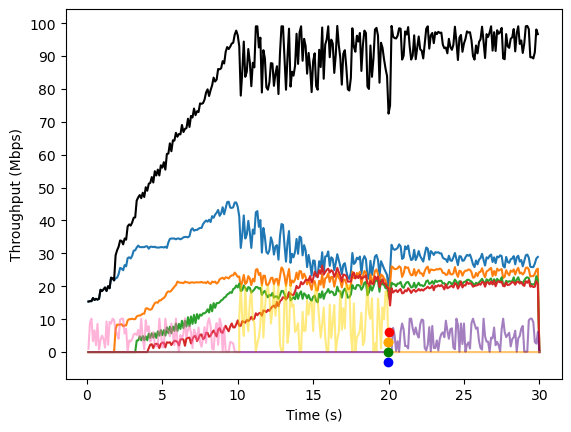

median ratio: 1.337802435241056


([94.4963328,
  94.743936,
  94.6296576,
  93.672576,
  93.4416384,
  94.2653952,
  93.3464064,
  93.886848,
  94.6296576],
 [2.3475230911599887,
  1.2679527757055495,
  1.337802435241056,
  2.09200532093452,
  1.286763588704651,
  1.3148899188876013,
  2.7232704402515724,
  1.3293148253096376,
  1.337802435241056],
 [2.359094457455113,
  1.3327469950161244,
  1.3662539591131588,
  2.1117154811715477,
  1.3681384248210022,
  1.3771804403774666,
  2.7644817073170733,
  1.4069803677157993,
  1.3662539591131588],
 [18.641887999999998,
  18.904899047619047,
  18.213368888888887,
  18.48276210526316,
  18.641887999999998,
  18.92757333333333,
  18.213368888888887,
  18.476496842105263,
  18.213368888888887])

In [11]:
iteration = 1
taxConstant = "4000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 93.68894399999999
median fairness: 1.2482785262624168
max fairness: 1.355648563576323


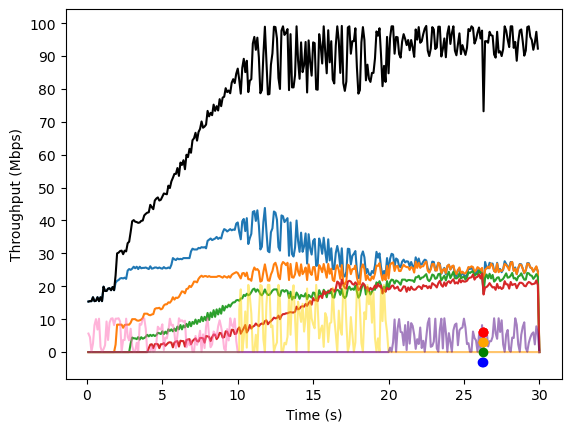

median ratio: 1.2432198499711482


([94.7772672,
  94.1654016,
  92.2821888,
  94.2653952,
  94.446336,
  93.5678208,
  93.4321152,
  92.5750272,
  94.446336],
 [1.2416737830913747,
  1.2533372025536855,
  1.2002581701571855,
  1.1804207119741101,
  1.2432198499711482,
  1.9601840534725876,
  1.426795150761579,
  1.9844210526315789,
  1.2432198499711482],
 [1.2684287812041117,
  1.3272297696396926,
  1.3840673575129534,
  1.202747252747253,
  1.2949363340242819,
  2.0808394869801785,
  1.4743833017077799,
  2.044266441821248,
  1.2949363340242819],
 [17.300728888888887,
  17.918567619047618,
  17.300728888888887,
  17.92423619047619,
  17.300728888888887,
  17.707424,
  17.918567619047618,
  17.511646315789474,
  17.300728888888887])

In [12]:
iteration = 1
taxConstant = "5000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 94.0811808
median fairness: 1.3462723940226609
max fairness: 1.4709235006306305


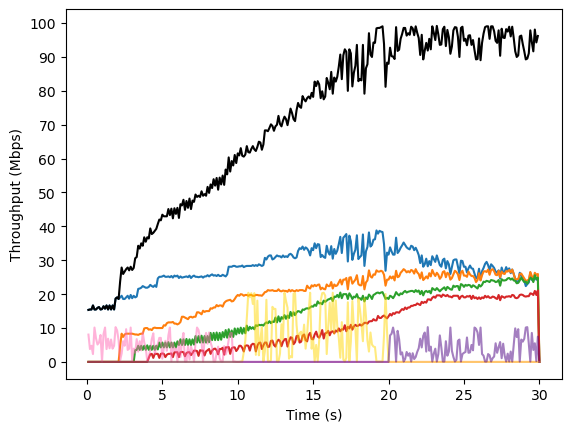

median ratio: 1.3236463386448083


([94.8653568,
  93.4273536,
  95.0867712,
  94.5844224,
  94.5249024,
  92.696448,
  94.291584,
  93.172608,
  94.8653568],
 [1.3236463386448083,
  1.3112511633575403,
  1.2882356673675335,
  1.4316409417139249,
  1.3688984494005134,
  1.3932328003485792,
  1.2629243032953255,
  1.4196627675964968,
  1.3236463386448083],
 [1.43414481897628,
  1.3406259495594046,
  1.3462897526501767,
  1.6095890410958902,
  1.507702182284981,
  1.5621074668527564,
  1.3175837320574164,
  1.638091946076737,
  1.43414481897628],
 [16.286019047619046,
  15.872248888888889,
  16.286019047619046,
  16.411490909090908,
  16.033044210526317,
  16.171808,
  15.872248888888889,
  16.033044210526317,
  16.286019047619046])

In [13]:
iteration = 1
taxConstant = "8000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 93.882384
median fairness: 1.6785049311565232
max fairness: 2.0902520385470718


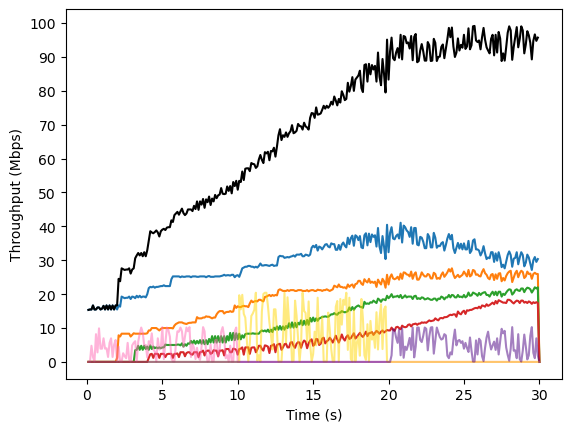

median ratio: 1.7134207870837534


([93.4011648,
  93.077376,
  94.6153728,
  94.4891904,
  94.0201728,
  93.7487616,
  93.6892416,
  94.017792,
  94.6153728],
 [1.570678792608855,
  1.742107012296444,
  1.7134207870837534,
  1.7268260727153621,
  1.7398177134975792,
  1.6088060663615174,
  1.5102018013429888,
  1.643589075229293,
  1.7134207870837534],
 [2.072970960536113,
  2.1022979985174204,
  2.0609665427509296,
  2.1240740740740742,
  2.115384615384615,
  2.0782060785767236,
  2.077151335311573,
  2.1515486725663715,
  2.0609665427509296],
 [15.928899047619048,
  15.872248888888889,
  15.914004210526315,
  15.892064,
  15.928899047619048,
  15.872248888888889,
  15.914004210526315,
  15.928899047619048,
  15.914004210526315])

In [14]:
iteration = 1
taxConstant = "10000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 31.8926016
median fairness: 5.376016260162602
max fairness: 5.404081632653061


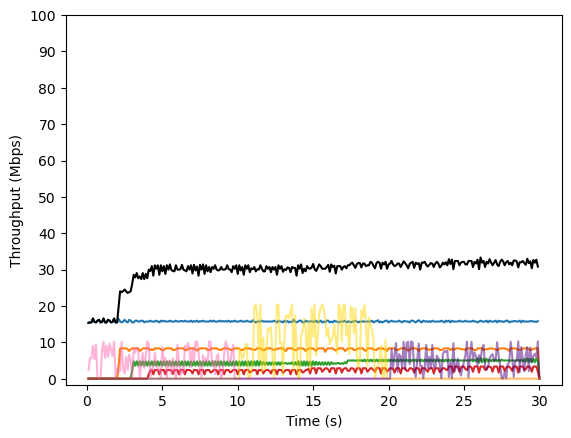

median ratio: 5.373983739837398


([31.8884352,
  31.9074816,
  31.890816,
  31.8860544,
  31.9051008,
  31.890816,
  31.886054400000003,
  31.8860544,
  31.890816],
 [5.380081300813008,
  5.360323886639676,
  5.373983739837398,
  5.373983739837398,
  5.342741935483871,
  5.378048780487805,
  5.394496861881208,
  5.39714867617108,
  5.373983739837398],
 [5.406122448979592,
  5.410204081632653,
  5.3999999999999995,
  5.408163265306123,
  5.404081632653061,
  5.404081632653061,
  5.404081632653061,
  5.404081632653061,
  5.3999999999999995],
 [15.782433684210526,
  15.798521904761905,
  15.767071999999999,
  15.782433684210526,
  15.792853333333333,
  15.782433684210526,
  15.782433684210526,
  15.798521904761904,
  15.767071999999999])

In [15]:
iteration = 1
taxConstant = "50000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
throughput: 30.196579200000002
median fairness: 7.565714285714286
max fairness: 7.571428571428573


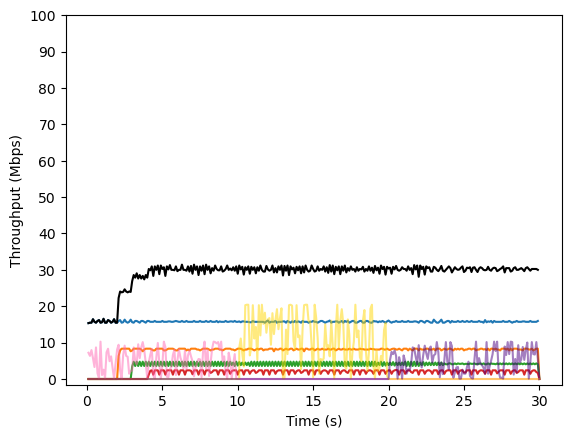

median ratio: 7.565714285714286


([30.1980672,
  30.188544,
  30.188544,
  30.212352000000003,
  30.195686400000003,
  30.1980672,
  30.193305600000002,
  30.1980672,
  30.188544],
 [7.554285714285715,
  7.565714285714286,
  7.565714285714286,
  7.565714285714286,
  7.568571428571429,
  7.565714285714286,
  7.5600000000000005,
  7.5600000000000005,
  7.565714285714286],
 [7.571428571428573,
  7.565714285714286,
  7.577142857142858,
  7.574285714285715,
  7.571428571428573,
  7.571428571428573,
  7.574285714285715,
  7.571428571428573,
  7.565714285714286],
 [15.804190476190476,
  15.767071999999999,
  15.799502222222221,
  15.767071999999999,
  15.799502222222221,
  15.809859047619048,
  15.782433684210526,
  15.798521904761905,
  15.767071999999999])

In [16]:
iteration = 1
taxConstant = "100000000"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 8):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [17]:
iqr_throughput = []
iqr_median_fairness = []
iqr_max_fairness = []
iqr_time = []
iqr_util_first2 = []

q25_throughput = []
q25_median_fairness = []
q25_max_fairness = []
q25_time = []
q25_util_first2 = []

q75_throughput = []
q75_median_fairness = []
q75_max_fairness = []
q75_time = []
q75_util_first2 = []

q50_throughput = []
q50_median_fairness = []
q50_max_fairness = []
q50_time = []
q50_util_first2 = []

throughput_upper_error = []
median_fairness_upper_error = []
max_fairness_upper_error = []
util_first2_upper_error = []

throughput_lower_error = []
median_fairness_lower_error = []
max_fairness_lower_error = []
util_first2_lower_error = []


print(len(labels))

new_labels = []
for index in range(0, len(labels)):
#     new_labels.append(str(int(labels[index]) / 1000000000))
    new_labels.append(labels[index])
    
print(new_labels)
    
df_throughput = pd.DataFrame({label: result for label, result in zip(labels, all_throughput_results)})

df_median_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_median_fairness_results)})

df_max_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_max_fairness_results)})

df_util_first2 = pd.DataFrame({label: result for label, result in zip(labels, all_first2_results)})


#calculate interquartile range of values of throughput, fairness, time and store in iqr array
for value in labels:
    q75, q50, q25 = np.percentile(df_throughput[str(value)], [75,50, 25])
    iqr = q75 - q25
    iqr_throughput.append(iqr)
    q25_throughput.append(q25)
    q50_throughput.append(q50)
    q75_throughput.append(q75)

    q75, q50, q25 = np.percentile(df_median_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_median_fairness.append(iqr)
    q25_median_fairness.append(q25)
    q50_median_fairness.append(q50)
    q75_median_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_max_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_max_fairness.append(iqr)
    q25_max_fairness.append(q25)
    q50_max_fairness.append(q50)
    q75_max_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_util_first2[value], [75,50, 25])
    iqr = q75 - q25
    iqr_util_first2.append(iqr)
    q25_util_first2.append(q25)
    q50_util_first2.append(q50)
    q75_util_first2.append(q75)
    
for value in labels:
    throughput_upper_error.append(q75_throughput[labels.index(value)] - q50_throughput[labels.index(value)])
    throughput_lower_error.append(q50_throughput[labels.index(value)] - q25_throughput[labels.index(value)])
    
    median_fairness_upper_error.append(q75_median_fairness[labels.index(value)] - q50_median_fairness[labels.index(value)])
    median_fairness_lower_error.append(q50_median_fairness[labels.index(value)] - q25_median_fairness[labels.index(value)])

    max_fairness_upper_error.append(q75_max_fairness[labels.index(value)] - q50_max_fairness[labels.index(value)])
    max_fairness_lower_error.append(q50_max_fairness[labels.index(value)] - q25_max_fairness[labels.index(value)])
    
    util_first2_upper_error.append(q75_util_first2[labels.index(value)] - q50_util_first2[labels.index(value)])
    util_first2_lower_error.append(q50_util_first2[labels.index(value)] - q25_util_first2[labels.index(value)])

13
['100000', '250000', '500000', '750000', '900000', '1000000', '3000000', '4000000', '5000000', '8000000', '10000000', '50000000', '100000000']


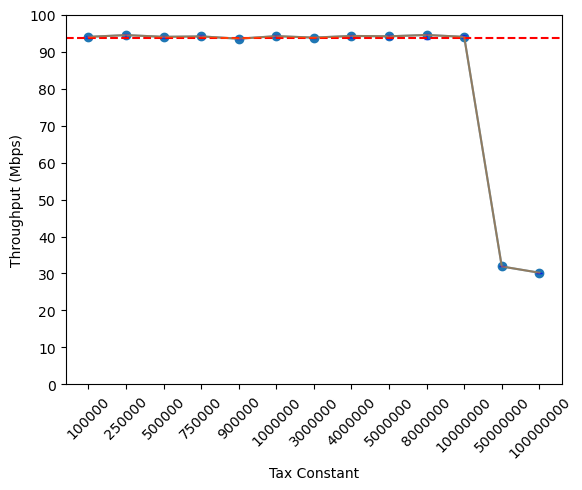

<Figure size 550x200 with 0 Axes>

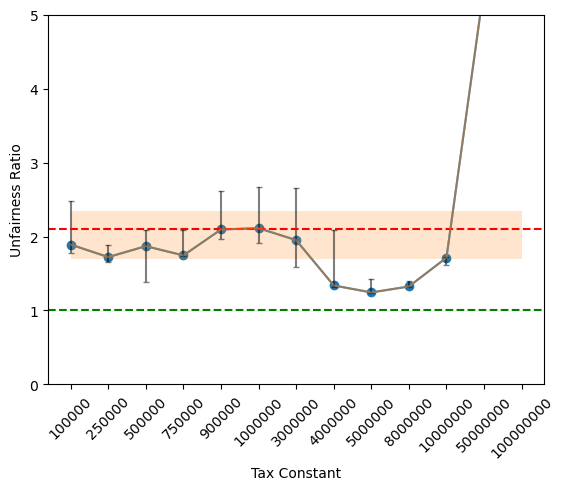

<Figure size 550x200 with 0 Axes>

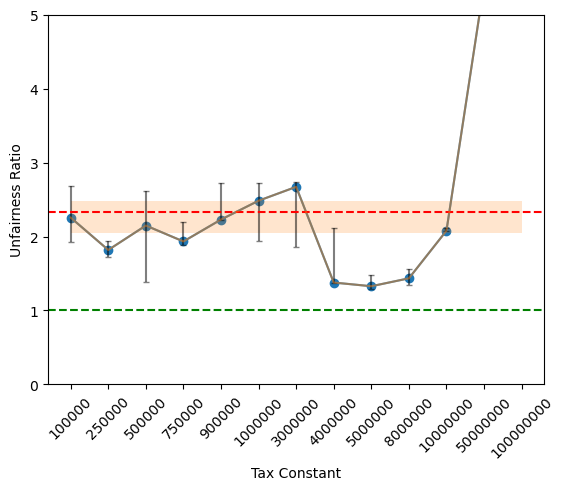

<Figure size 550x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [18]:
######################### Tax Constant vs Throughput  ###############
plt.xlabel('Tax Constant')
plt.ylabel('Throughput (Mbps)')
plt.scatter(new_labels, q50_throughput)
# # plt.scatter(new_labels, q50_util_first2)
plt.plot(new_labels, q50_throughput)
# plt.plot(new_labels, q50_util_first2)
plt.errorbar(new_labels, q50_throughput, yerr=[throughput_lower_error, throughput_upper_error], alpha=0.5, ecolor='blue', capsize=2)
# plt.errorbar(new_labels, q50_util_first2, yerr=[util_first2_lower_error, util_first2_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
yticks = np.arange(0, 110, 10)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Median Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_median_fairness)
plt.plot(new_labels, q50_median_fairness)
plt.errorbar(new_labels, q50_median_fairness, yerr=[median_fairness_lower_error, median_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.338430892173957, 1.690309802093696, alpha=0.2)
yticks = np.arange(0, 6, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Max Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_max_fairness)
plt.plot(new_labels, q50_max_fairness)
plt.errorbar(new_labels, q50_max_fairness, yerr=[max_fairness_lower_error, max_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_max_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.478789005632077, 2.041943714018822, alpha=0.2)
yticks = np.arange(0, 7, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()